# ViT vs. CNN

| 核心维度 | ViT | CNN |
|---|---|---|
| 核心操作 | 自注意力（全局关联） | 卷积（局部滤波） |
| 归纳偏置 | 无显式偏置，数据驱动 | 强空间局部性、平移等变性 |
| 数据需求 | 依赖大规模预训练 | 中小规模数据高效 |
| 长程依赖建模 | 单层即可全局交互 | 需深层堆叠或特殊模块（如 Non-local） |
| 计算复杂度 | 平方增长（需分块优化） | 线性增长（与图像大小） |
| 可解释性 | 原生注意力热力图 | 依赖类激活图（CAM） |
| 典型应用场景 | 大数据预训练、跨模态任务 | 实时检测、边缘设备 |

ViT 可以建立图像块之间的联系（如猫头与猫尾）。

**ViT 需超大规模预训练**：ViT 缺乏 CNN 自带的局部性、平移等变性等空间先验，需要依靠超大规模数据自行学习这些视觉规律。

CNN 在小数据、资源受限场景更优。

# 流程

1. Linear Projection of Flattened Patches：​获取完整的线性嵌入
- ​Patch Embedding​
- Classification Token
- Positional Embedding

2. Transformer Encoder：​提取特征
- n * Transformer Encoder Layer(s)

3. MLP Head：​最终的分类层

## Patch Embedding

切分图像块（Patch）：
$$H长度 \times W宽度 \times C通道数 \Rightarrow N块个数 \times (P块边长^2 \times C), \text{where } N = HW / P^2$$


Embedding：

每个 patch 被展平（flatten）并通过一个线性变换（即一个全连接层）映射到一个固定的维度 D，形成每个 patch 的 embedding 向量。

```text
Eg:
patch：16 x 16 x 3
展平：1 x 768（16 x 16 x 3）的 token
共有 14 x 14 = 196 个 patch
最终矩阵：196 x 768
```

## Classification Token

在 patch embedding 上添加一个 classification token[cls]，让 Transformer 在整个图像的上下文中获取全局信息，供下游任务使用。

添加形式：
$$X' = [CLS; X_1; X_2; \dots; X_N]$$

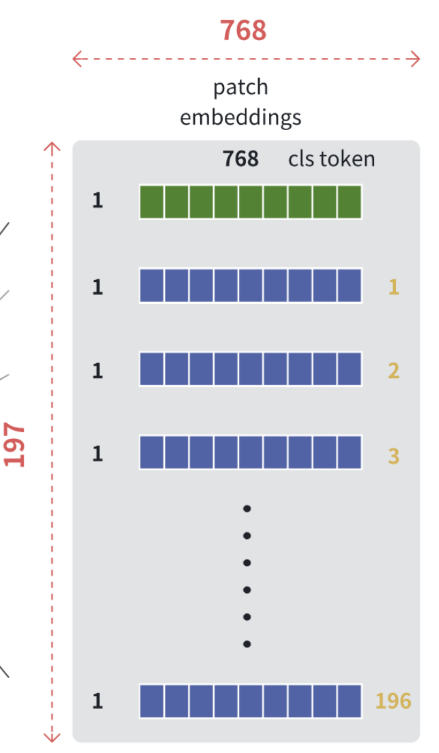

**为什么 [CLS] Token 能代表全局信息？**

- 在每一层 Transformer 中，[CLS] Token 作为 **Query**，与所有 Token（包括自己）进行注意力计算。

- 由于 [CLS] Token 参与了多层 Transformer 的注意力计算，它会学习到整个图像的全局信息。

- 最终，经过多层 Transformer 计算后，[CLS] Token 变成了图像的全局表示，可用于分类任务。

**做图像分类时，最后只使用 [CLS] Token 的输出进行分类**

最后，[CLS] Token 的表示会输入到一个 MLP（多层感知机）分类器，执行分类：
$$y = MLP\left(Z^{CLS}_{L}\right)$$

## Positional Embedding

$E_{pos}$ 是可学习向量。

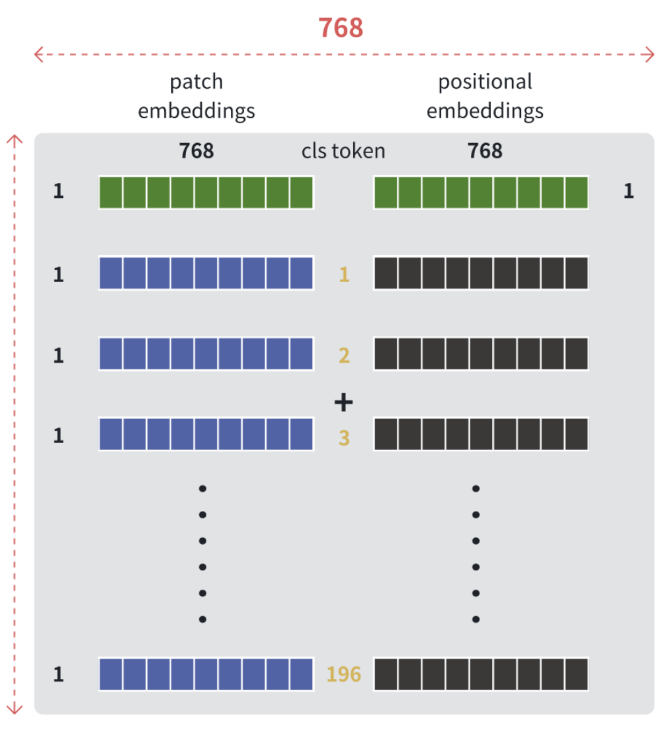

## Transformer Encoder

根据输入的向量信息，提取特征：
$$X_{input} = X_{cls+patch} + E_{pos}$$

该模块多层堆叠：

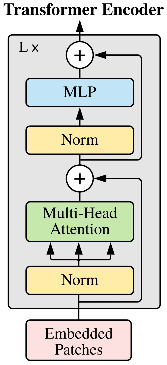

### Norm 选择：LayerNorm

输入：[Batch 批次大小, Sequence 序列长度, Dimension 特征维度]（即 [N, L, D]）

- LayerNorm (LN)：跨特征（Feature），对同一个样本进行归一化。（“个人自我评估”）

    针对每一个单独的样本（每一张图），把它所有的 L 和 D 维度拉平，计算出一个均值和一个方差。
- BatchNorm (BN)：跨样本（Batch），对同一个特征进行归一化。（“全班统一标准”）

    针对每一个特征位置（每一个维度 D），把整个 Batch 中所有样本（N）和所有序列位置（L）的数值拿出来，计算出一个均值和一个方差。

**为什么 ViT 会使用 LayerNorm 而不是 BatchNorm？**

- BN 对 Batch Size 的致命依赖：Transformer 显存消耗大，一般使用小的 Batch Size，分母小，均值和方差会剧烈波动。

- 序列长度可变，LN 在单句内归一化，较好适应。

- LN 能保持一个样本内部不同特征之间的相对大小关系，不会破坏样本内部结构。

## MLP Head：最终分类

把这串人类看不懂的抽象向量，翻译成人类能看懂的具体类别概率。

[CLS] -> Linear(768, 768) -> Tanh/GELU 激活函数 -> Dropout -> Linear(768, 1000)

- Linear(768, 768)：全连接层。特征的内部表示被彻底重组了，换个角度审视特征。**赋予模型“创造新特征组合”的能力**

- Tanh/GELU 激活函数：非线性变换，打破线性关系。赋予了模型拟合极其复杂、弯曲的决策边界的能力

- Dropout(0.1)：随机把一部分神经元置 0，防止过拟合

- Linear(768, 1000)：分类映射


# 训练与微调

<mark>**大规模预训练 + 迁移学习（微调）**</mark>

- 先在超大数据集上预训练：学习通用的视觉特征
- 再在小数据集上微调：适应具体任务

## 预训练阶段

**使用线性分类头**

Transformer输出(768维) → Linear(768, K) → K(预训练数据集的类别数)个类别分数

## 迁移学习/微调阶段

去掉原来的 Linear(768, 21000)

替换为新的 Linear(768, K‘)  # K’是新任务的类别数

# Other

## 既然有这么多参数要更新，模型怎么知道这里更新的特征是位置，那里更新的特征是位置编码等？

这是一个非常深刻且直击神经网络本质的问题！

直接给出反直觉的答案：**模型其实“完全不知道”什么是位置，什么是内容，什么是 cls。** 

神经网络内部没有任何“语义标签”或“角色分配器”。它不懂图像，不懂空间，它只知道一个纯粹的数学目标：**调整所有参数，让最终的损失函数（Loss）尽可能小。**

那么，既然模型“什么都不知道”，为什么最终训练出来的结果，却神奇地出现了“位置编码专门负责位置，Patch Embedding 专门负责内容”的明确分工呢？

这归功于**人类设计的架构约束**与**梯度下降的优化动力学**共同产生的 **“涌现行为”（Emergent Behavior）**。具体通过以下三个机制实现：

---

### 机制一：人类设计的“物理隔离”（架构约束）

虽然模型不懂语义，但**我们在写代码时，强制规定了数据的流向和参数的独立性**。

在 PyTorch 等框架中，位置编码（Position Embedding）被定义为一个**完全独立的、可学习的参数张量**（例如 `nn.Parameter(torch.randn(1, N+1, D))`）。
* **关键点**：这个张量**不接收任何图像像素作为输入**。无论输入的是猫、狗还是全黑的图片，位置编码的初始值都是固定不变的。
* 相反，Patch Embedding 层（如卷积或线性层）**只接收局部图像像素作为输入**。

这种代码层面的“物理隔离”，意味着在反向传播时，梯度只能沿着这些预设的“管道”流动。模型无法用一个参数同时去“记住”像素颜色和绝对坐标，因为它们在计算图中是两条独立的分支，只是在最后一步被**相加（Add）** 在了一起。

### 机制二：梯度的“精准打击”（计算图的反向传播）

让我们用一个具体的错误例子，看看梯度是如何“教”模型分工的。

**假设场景**：模型看到一张图，左上角有“猫耳朵”的像素，右下角有“猫尾巴”的像素。但模型错误地把它分类成了“狗”。
**原因分析**：模型内部的 Attention 机制可能把“左上角的特征”和“右下角的特征”错误地关联了。

此时，Loss 变大，反向传播开始：
1. 梯度会流向 **Attention 的权重**，告诉它：“你刚才的关联方式错了，下次换个方式关联”。
2. 梯度**同时**会流向相加之前的两个分支：
   * 流向 **Patch Embedding**：“你提取的‘猫耳朵’特征向量不够有辨识度，调整一下你的卷积核权重”。
   * 流向 **位置编码**：“你提供给‘左上角’的那个位置向量，没能很好地帮助 Attention 区分它和‘右下角’，**请修改‘左上角’对应的那个位置向量的数值**”。

**神奇之处在于**：因为位置编码矩阵中，“左上角”的向量是独立存在的，梯度会**专门修改这个向量**，让它变成一个独特的“左上角指纹”。它不会去修改“右下角”的位置向量，也不会去修改提取颜色的权重。梯度通过链式法则，自动实现了“谁的责任谁承担”。

### 机制三：优化的“省力原则”（表征解耦 Disentanglement）

你可能会问：模型能不能“耍赖”，让 Patch Embedding 既学内容又学位置，而让位置编码学点别的？

理论上可以，但在实际的优化景观（Optimization Landscape）中，**“分工合作”是损失函数下降最快、最稳定的路径（即最优解）**。

* **如果混合学习**：假设 Patch Embedding 试图同时编码“这是一只耳朵”和“这在左上角”。那么当同一只耳朵出现在**右上角**时，Patch Embedding 就会陷入混乱，因为它之前学的权重被“左上角”绑死了。这会导致 Loss 很难降下来。
* **如果解耦学习（分工）**：优化器（如 Adam）在海量数据的训练中会发现一个“省力”的捷径：
  * 让 Patch Embedding **只关注“这是什么”**（无论在哪，猫耳朵的纹理特征都是一样的）。
  * 让 Position Embedding **只关注“这是在哪”**（无论这是什么像素，左上角的位置标识都是一样的）。
  * 两者**相加**后，Attention 就能轻松得到“左上角的猫耳朵”这个完整概念。

这种“解耦”（Disentanglement）的表征方式，泛化能力最强，梯度下降最容易收敛。因此，模型“自发”地演化出了这种明确的分工。

---

### 一个通俗的比喻：盲人公司

想象一家由盲人组成的分类公司（神经网络）：
1. **触觉员（Patch Embedding）**：只负责摸物体，报告“这是毛茸茸的”、“这是硬的”。他不知道物体在房间的哪个位置。
2. **测距员（Position Embedding）**：只负责报坐标，“这是坐标(0,0)”、“这是坐标(1,1)”。他不知道摸到的是什么东西。
3. **经理（Attention）**：接收触觉员和测距员的报告（相加），综合判断：“坐标(0,0)的毛茸茸物体 + 坐标(1,1)的硬物体 = 这是一只猫”。

如果公司判断错了（Loss 高），老板（反向传播）会骂人。
老板**不需要知道**谁是触觉员、谁是测距员。老板只需要根据最终结果，沿着汇报链条（计算图）追责：
* “触觉员，你下次把毛茸茸的感觉描述得更准确点！”（更新 Patch Embedding 权重）
* “测距员，你报的坐标(0,0)没能帮经理区分左右，下次换个报法！”（更新 Position Embedding 参数）

久而久之，即使老板从不解释“什么是位置”、“什么是触觉”，这两个员工也会**自发地**形成完美的专业分工，因为这是让公司存活（Loss 最小化）的唯一方式。

### 总结
模型不知道什么是位置。是**人类通过代码隔离了参数**，**反向传播的梯度顺着计算图精准修改了对应的独立参数**，而**优化算法为了最小化误差，自发地选择了“内容与位置解耦”这种最高效的分工策略**。这就是深度学习中迷人的“涌现”现象。